<a href="https://colab.research.google.com/github/cuiandrew08-lab/LiDARFusionLearning/blob/main/LiDARbaseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nuscenes: https://colab.research.google.com/github/nutonomy/nuscenes-devkit/blob/master/python-sdk/tutorials/nuscenes_tutorial.ipynb#scrollTo=Q0WfcmMM2TMa

Open3d: https://colab.research.google.com/drive/1lwLt3j5vEilNKPSqPir0nH7aT8MwGIgZ?usp=sharing#scrollTo=w2Zgsfonla65

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from tqdm.notebook import tqdm
from PIL import Image

import tensorflow as tf

import os

from google.colab import drive
drive.mount("/content/drive")

TORCH_version = torch.__version__.split('+')[0]
CUDA_version = torch.version.cuda.replace('.', '')

!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-{TORCH_version}+cu{CUDA_version}.html

!pip install torch_geometric

import torch_geometric as pyg

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MLP, global_add_pool
from torch_geometric.nn.conv import HANConv

from torch_geometric.transforms import NormalizeFeatures

!pip install open3d plotly

import open3d as o3d
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html


In [2]:
!mkdir -p /data/sets/nuscenes  # Make the directory to store the nuScenes dataset in.

#!cp "/content/drive/MyDrive/LiDARFusion/v1.0-mini.tgz" "/data/sets/nuscenes"

!tar -xf "/content/drive/MyDrive/LiDARFusion/v1.0-mini.tgz" -C /data/sets/nuscenes  # Uncompress the nuScenes mini split.

!pip install nuscenes-devkit &> /dev/null  # Install nuScenes.

In [3]:
import sys

sys.path.insert(0, '/content/drive/MyDrive/LiDARFusion')

from voxel_pointnet2 import PointNetSetAbstraction

#each voxel is encoded as [B,N,C]. B=batch dimension, N = max num per voxel, C is either features, or 3 if coordinates
#a [B,N] mask controls which points in a batch are considered padding, and which are considered actual points for processing
#raw coordinates and raw features are often stored in separate variables, coordinates -> xyz, features -> points
#npoint is how many centroids to select, nsample is how many points exist in each centroid neighborhood

#returns both new_xyz -coordinates, and new_points - features

In [2]:
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
nusc_root = "/data/sets/nuscenes"

nusc = NuScenes(version='v1.0-mini', dataroot=nusc_root, verbose=True)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.508 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


nusc.get("sample_data", id for sensor), id is through sample["data"]["Sensor name"]

nusc.render_sample_data(data["token"])

In [ ]:
my_scene = nusc.scene[0] #0-9
first_sample_token = my_scene['first_sample_token']
my_sample = nusc.get('sample', first_sample_token)
lidar_data = nusc.get('sample_data', my_sample['data']["LIDAR_TOP"])
#nusc.render_sample_data(cam_front_data['token'])
lidar_data_path = os.path.join(nusc_root, lidar_data["filename"])
pc = LidarPointCloud.from_file(lidar_data_path)

When changing to storing on drive, only need to change the nusc_root data path

In [4]:
def extract_clouds(scene, data_root):

  scene_tokens = []
  token_0 = scene["first_sample_token"]

  while token_0 != "":
    scene_tokens.append(token_0)

    token_sample = nusc.get("sample", token_0)
    token_0 = token_sample["next"]

  scene_clouds = []

  for i in range(len(scene_tokens)):
    cloud_sample = nusc.get("sample", scene_tokens[i])
    cloud_data = nusc.get("sample_data", cloud_sample["data"]["LIDAR_TOP"])

    cloud_root = os.path.join(data_root, cloud_data["filename"])

    cloud = LidarPointCloud.from_file(cloud_root)

    cloud_xyz = cloud.points[:3, :].T

    lidar_cloud = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(cloud_xyz))

    scene_clouds.append(lidar_cloud)

  return scene_clouds


In [38]:
def get_point_pillar(point, min, voxel_size, cols):

  i = np.floor((point[0]-min[0])/voxel_size)
  j = np.floor((point[1]-min[1])/voxel_size)

  pillar_index = (j*cols + i).astype(int)


  return pillar_index


In [ ]:
def get_ij(point, min, voxel_size):


  i = np.floor((point[0]-min[0])/voxel_size)
  j = np.floor((point[1]-min[1])/voxel_size)

  return i,j

In [39]:
def get_pillars(cloud, voxel_size = 1, pillar_max = 100): #voxel_size is length of one side of voxel

  voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(cloud, voxel_size=voxel_size)

  min_bound = voxel_grid.get_min_bound()
  max_bound = voxel_grid.get_max_bound()

  print(min_bound, max_bound)

  voxel_shape = np.ceil((max_bound - min_bound) / voxel_size).astype(int)

  cloud_array = np.asarray(cloud.points)

  T = voxel_shape[0]*voxel_shape[1]

  N_counter = np.zeros(T)

  for k in range(cloud_array.shape[0]):
    point = cloud_array[k]

    p_index = get_point_pillar(point, min_bound, voxel_size, voxel_shape[0])

    N_counter[p_index] += 1

  N = (np.max(N_counter)).astype(int)

  if pillar_max < N or pillar_max == None:
    N = pillar_max

  out = np.zeros((T, N, 3))

  mask = np.zeros((T), dtype = int)

  for m in range(cloud_array.shape[0]):
    point = cloud_array[m]

    p_index = get_point_pillar(point, min_bound, voxel_size, voxel_shape[0])

    k = mask[p_index]

    if k < N:
      out[p_index][k] = point

      mask[p_index] += 1

  out_zeros = ~np.all(out == 0, axis=(1, 2))

  out = out[out_zeros,:,:]

  mask = mask[mask != 0] #mask returns how many non-padded points are in each pillar. Zero points in a pillar are assumed to be padded unless the mask indicates otherwise

  out = torch.from_numpy(out).float()
  mask = torch.from_numpy(mask).float()

  return out, mask



In [14]:
class PillarsEncoder(nn.Module):


  def __init__(self, extra_features = 0, sa1_npoint=16, sa1_radius=0.6, sa1_nsample=16, sa1_mlp=[32, 64], sa2_mlp=[64, 128, 256]):

    super().__init__()
    self.sa1 = PointNetSetAbstraction(npoint=sa1_npoint, radius=sa1_radius, nsample=sa1_nsample, in_channel=3 + extra_features, mlp_channels=sa1_mlp, group_all=False)
    self.aggregate = PointNetSetAbstraction(npoint = None, radius = None, nsample = None, in_channel = 3 + sa1_mlp[-1], mlp_channels = sa2_mlp, group_all = True)

    self.out_dim = sa2_mlp[-1]

  def forward(self, pillars, num_points):

    B, N, C = pillars.shape

    arr = torch.arange(N, device = num_points.device).unsqueeze(0)
    mask = arr < num_points.unsqueeze(1)

    xyz = pillars[..., :3].clone()

    if C > 3:
      feats = pillars[..., 3:]

    else:
      feats = None

    sums = (xyz * mask.unsqueeze(-1)).sum(dim=1)
    centers = sums / num_points.clamp(min=1).unsqueeze(-1).to(xyz.dtype)
    xyz = (xyz - centers.unsqueeze(1)) * mask.unsqueeze(-1)

    l1_xyz, l1_points, l1_mask = self.sa1(xyz, feats, mask)

    _, l2_points, _ = self.aggregate(l1_xyz, l1_points, l1_mask)

    return l2_points.squeeze(1)

In [51]:
def get_centroids(pillars, mask):

  centroids = np.zeros((pillars.shape[0],pillars.shape[-1]))

  for i in range(pillars.shape[0]):
    sum = pillars[i].sum(axis = 0)
    centroids[i] = sum/mask[i]

  return centroids


In [9]:
test_scene = nusc.scene[2]
test_clouds = extract_clouds(test_scene, nusc_root)

In [42]:
test_cl = test_clouds[6]

pillars_test = get_pillars(test_cl)

[-77.45300293 -95.58469391  -7.07759428] [95.54699707 86.41530609 13.92240572]


In [43]:
print(pillars_test[0].shape)

torch.Size([1296, 100, 3])


In [44]:
model = PillarsEncoder()

pillars = pillars_test[0]
mask = pillars_test[1]


out = model(pillars, mask)

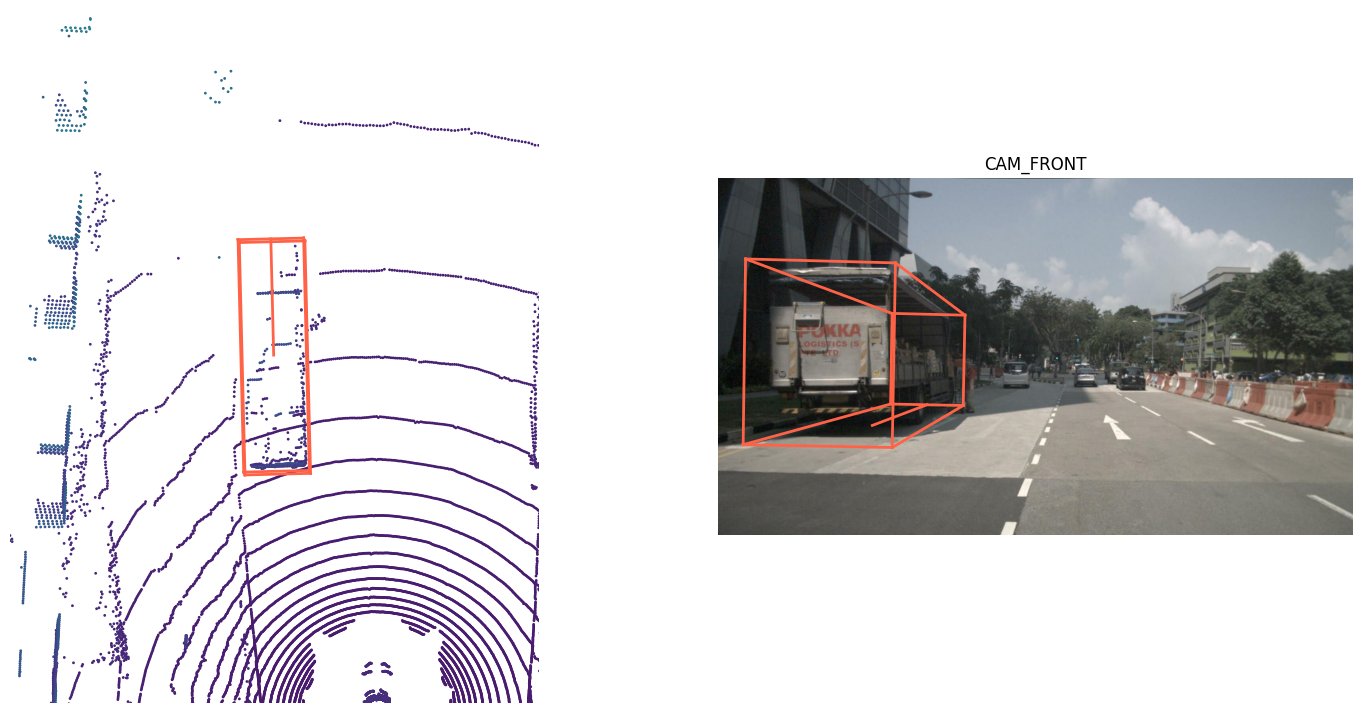

In [ ]:
annotation_token = my_sample["anns"][18]
annotation_metadata =  nusc.get('sample_annotation', annotation_token)
nusc.render_annotation(annotation_token)